<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# TS1: Síntesis y operaciones de señales
#### Sofía Makkos


En este trabajo se diseñarán 5 tipos de señales (más una extra), siendo estas de funciones, frecuencias y potencias distintas. En todas ellas, se utilizará la misma cantidad de muestras N=1000. Se graficará la señal misma, el módulo de su FFT y y la FFT representada en dB, y a cada una de estas figuras se le buscará un sentido y se las relacionará entre sí.

También, se tendrá en cuenta el código a utilizar, es decir, lo proveniente de las librerías implementadas. Las funciones utilizadas tendrán parámetros que se variarán dependiendo de lo pedido, como es el caso de la varianza, que llevará cálculos externos.

Se utilizarán las siguientes librerías:

In [1]:
import numpy as np
from scipy.fft import fft, fftfreq
from scipy.signal import square, sawtooth
import matplotlib.pyplot as plt

N=1000

#### 1° señal: 
Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.

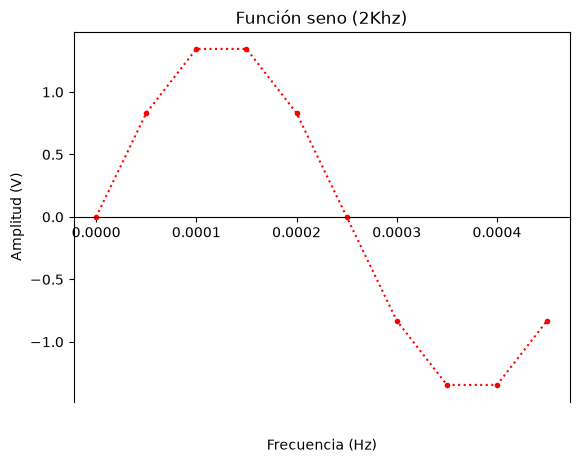

In [2]:
fs=20000

def mi_funcion_sen( vmax = np.sqrt(2), dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    tt=np.arange(0.0, N/fs, 1/fs)
    xx=vmax*np.sin(2*np.pi*ff*tt +ph)+dc
    return(tt, xx)
tt, xx= mi_funcion_sen(ff=2000)

plt.figure(1)
plt.plot(tt[:10],xx[:10], ":.", color="red")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")
plt.title("Función seno (2Khz)")
plt.gca().spines['bottom'].set_position('zero')
plt.gca().xaxis.set_label_coords(0.5, -0.1)

Utilicé la función seno originada en el TS0 para simplificación de cuentas. Para que la señal sinusoidal disponga de una frecuencia de 2kHz, se le indicó este valor (2000) a la variable *ff*.
Por otro lado, se buscó que la función tenga por lo menos 10 puntos por período. Para eso, se tuvo en cuenta la siguiente relación:
\begin{equation}
T=\frac{M}{fs}=\frac{1}{ff} \Longrightarrow M*fs=ff
\end{equation}
*M* siendo la cantidad de puntos por período y *fs* la frecuencia de muestreo. Es así, que determinamos que *fs*=20000.
Por otro lado, para mejor ilustración, al momento de graficar la función, se decidió que que en la función *plt.plot* se tomen valores temporales y espaciales que indiquen un solo período realizado.

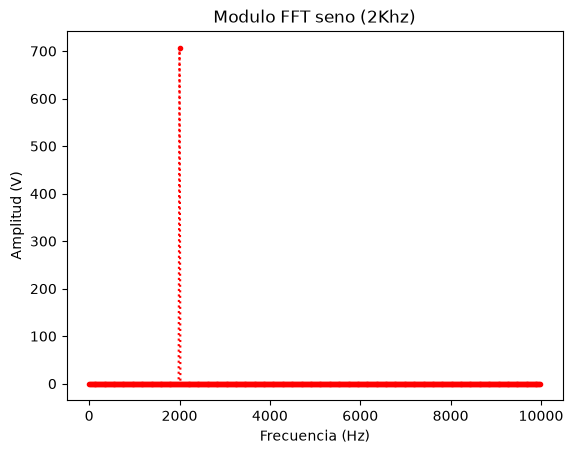

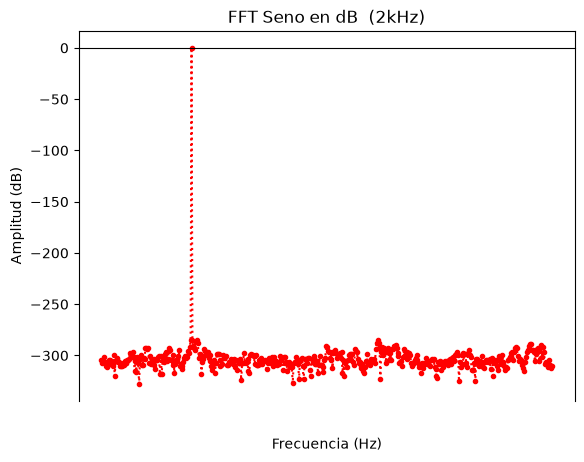

In [3]:
fftxx = fft(xx)
fftxx = fftxx[:N//2]
freq = fftfreq(N,1/fs)
freq = freq[:N//2]
fftxx_abs = np.abs(fftxx)

plt.figure(2)
plt.plot(freq,fftxx_abs, ":.", color="red")
plt.title("Modulo FFT seno (2Khz)")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

ref=np.max(fftxx_abs)
fftxx_abs_dB=20*np.log10(fftxx_abs/ref)

plt.figure(3)
plt.plot(freq, fftxx_abs_dB, ":.", color="red")
plt.title("FFT Seno en dB  (2kHz)")
plt.gca().spines['bottom'].set_position('zero')
plt.xticks([], [])
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

Posteriormente, se calculó el Fast Fourier Transform de la función seno, se tomó la primera mitad de sus valores absolutos, y se creó una frecuencia *freq* acorde con los valores utilizados, para realizar el gráfico correspondiente. Su amplitud máxima es de:

In [4]:
print(ref)

707.1067811865478


Se ve que solo hay "un pulso", coincidiente con su frecuencia *ff*=2000, debido a su comportamiento sinusoidal. Sabemos que las funciones trigonométricas seno y coseno disponen de dos deltas cada una. En este caso se redujo la FFT del seno a la mitad de sus valores, por lo que no es posible visualizar el segundo delta.

También se realizó el gráfico normalizado de la función en decibeles. Para este caso, se buscó que la función seno sea de 1W, detalle que probablemente pasó desprevenido anteriormente; al poner una amplitud de $\surd2$, la potencia será de manera:

In [5]:
print(np.var(xx))

1.0000000000000007


Consecuentemente, esta señal senoidal será de referencia para las siguientes funciones a aplicar.

#### 2° señal: 
Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período, con 2 W de potencia media y desfasada en π/2.

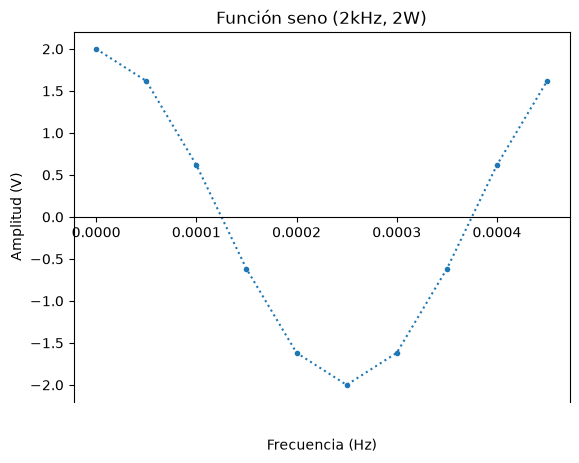

In [6]:
tt, xx= mi_funcion_sen(vmax=2,ff=2000, ph=np.pi/2)

plt.figure(4)
plt.plot(tt[:10],xx[:10], ":.")
plt.title("Función seno (2kHz, 2W)")
plt.gca().spines['bottom'].set_position('zero')
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

Para la segunda señal se emplaron las mismas ideas que en la anterior, con respecto a la frecuencia y la cantidad de muestras por período.
En cuanto a la potencia media, se correspondió a la siguiente fórmula (válida para señales sinusoidales):
\begin{equation}
P_{media}=\frac{1}{N}*\sum_{n=0}^{N-1} x^2=\frac{a^2}{2} 
\end{equation}

Como se requiere de una potencia media de 2W, se deduce de la fórmula que *a*=2, lo cual se puede apreciar en la figura de la función a partir de la amplitud.

También, el enunciado indicó un desfasaje de $\frac{\pi}{2}$, así que en la función *mi_funcion_sen* se cambió el valor del parámetro *ph*

Se puede comparar entonces las dos funciones elaboradas hasta ahora. Cuentan con misma frecuencia y cantidad de puntos por período, sin embargo, la amplitud de la segunda sinusoidal se duplica en comparación a la primera, a la vez que la ordenada del origen se ve modificada por el desfasaje.

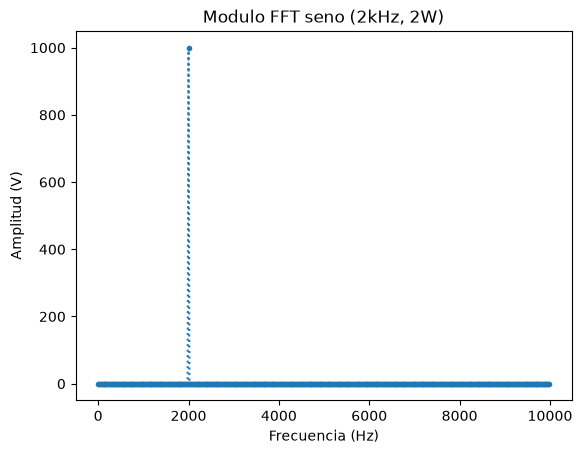

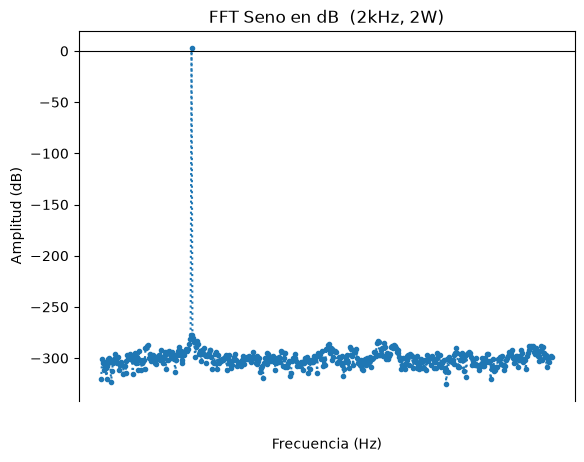

In [7]:
fs=20000
fftxx = fft(xx)
fftxx = fftxx[:N//2]
#print(fftxx[k])
freq = fftfreq(N,1/fs)
freq = freq[:N//2]
fftxx_abs = np.abs(fftxx)

plt.figure(5)
plt.plot(freq,fftxx_abs, ":.")
plt.title("Modulo FFT seno (2kHz, 2W)")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

fftxx_abs_dB=20*np.log10(fftxx_abs/ref)

plt.figure(6)
plt.plot(freq, fftxx_abs_dB, ":.")
plt.title("FFT Seno en dB  (2kHz, 2W)")
plt.gca().spines['bottom'].set_position('zero')
plt.xticks([], [])
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

Al realizar el FFT para esta segunda senoidal, podemos observar que su amplitud máxima cambió (700$\rightarrow$1000). Esto se debe al cambio de amplitud aplicado a la función *mi_funcion_sen*, es decir, el cambio de la potencia. Se debe destacar, que el cambio de fase no generó cambios, por ejemplo, en la frecuencia.

A continuación, contamos con el gráfico de la FFT representado en decibeles, como se dijo previamente, en referencia a la potencia del primer seno (de 1W). Si buscamos el valor en dB en la frecuencia de 2000Hz, tenemos que:

In [8]:
print(fftxx_abs_dB[freq==2000])

[3.01029996]


El resultado deriva justamente de la siguiente fórmula:
\begin{equation}
P_{dB}=10*log_{10}(\frac{P}{P_{ref}}) \Longrightarrow P_{dB}=10*log_{10}(\frac{2W}{1W})\approx3
\end{equation}
La fórmula utilizada en el código proviene, en cambio, de las amplitudes de sus FFT, entonces:
\begin{equation}
A_{dB}=20*log_{10}(\frac{A}{A_{ref}}) \Longrightarrow A_{dB}=20*log_{10}(\frac{1000}{707})\approx3
\end{equation}

#### 3° Señal:
Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.


Text(0.5, -0.1, 'Frecuencia (Hz)')

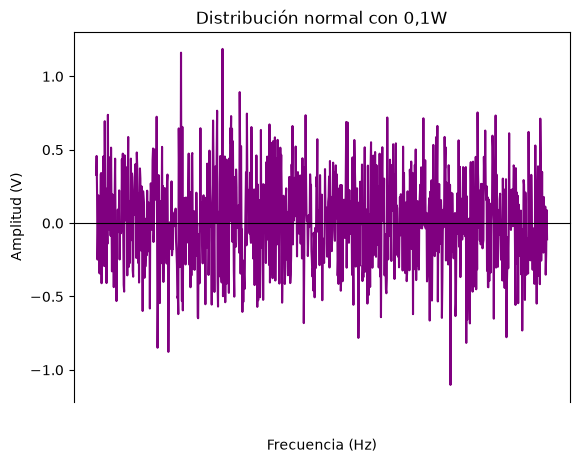

In [9]:
tt=np.arange(N)
fs=1000
norm=np.random.normal(scale=np.sqrt(0.1),size=len(tt))

plt.figure(5)
plt.plot(tt, norm, color="purple")
plt.title("Distribución normal con 0,1W")
plt.gca().spines['bottom'].set_position('zero')
plt.gca().xaxis.set_label_coords(0.5, -0.1)
plt.xticks([], [])
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

Para que la distribución normal sea de 0,1W, simplemente se indicó en la función *np.random.normal* la escala sea de $\sqrt{0,1}$, la cual representa la desviación estandar $\sigma^2$. Como muestra luego la función *np.var*, efectivamente la potencia de la función es aproximadamente de 0,1W. A la vez, para que este ruido tenga valor medio de 0V, la función *np.random.normal* cuenta con un parámetro *loc*, el cual mraca la media (centro) de la distribución. Su valor predeterminado es de 0, por lo que no requiere alteraciones en la función.

In [10]:
print(np.var(norm))

0.09780413140459192


Text(0.5, 0, 'Frecuencia (Hz)')

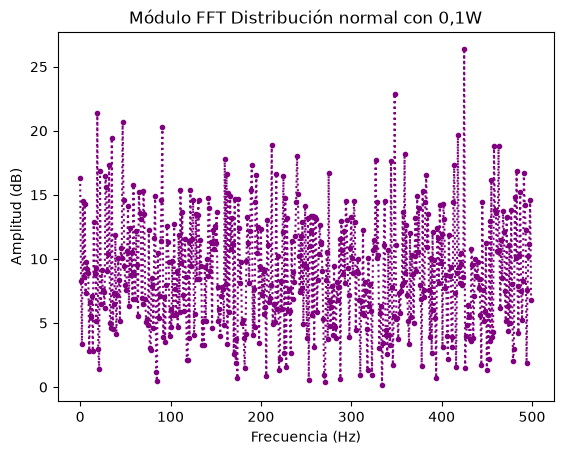

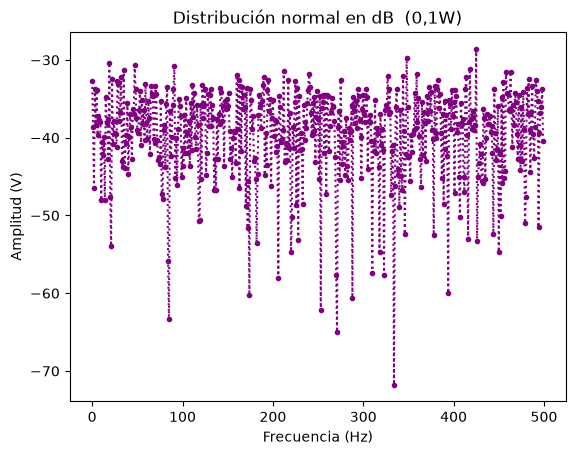

In [11]:
fftnorm = fft(norm)
fftnorm = fftnorm[:N//2]
fftnorm_abs = np.abs(fftnorm)
freq = fftfreq(N,1/fs)
freq = freq[:N//2]

plt.figure(8)
plt.plot(freq,fftnorm_abs, ":.",color="purple")
plt.title("Módulo FFT Distribución normal con 0,1W")
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")

fftnorm_abs_dB=20*np.log10(fftnorm_abs/ref)

plt.figure(9)
plt.plot(freq, fftnorm_abs_dB, ":.",color="purple")
plt.title("Distribución normal en dB  (0,1W)")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

Para representar el módulo de la FFT del ruido de distribución normal, se realizaron los mismos pasos que antes, en cuanto al uso de la función *fft* y la inicialización de una frecuencia *freq* para el gráfico. Esta vez, no podemos distinguir pulsos especificos, debido a que esta señal sigue un orden aleatorio, sin ser un seno o coseno definido.

Si comparamos el gráfico del módulo FFT y de la FFT en dB, se puede notar un patrón que se repite también en las primeras dos funciones analizadas, aunque acá se encuentra más disimulado; la frecuencia de la máxima amplitud del primer gráfico coincide con la del segundo. Esta frecuencia siempre cambiará, debido a que la función *np.random.norm* genera ruidos aleatorios, siempre respentado los parámetros indicados (*loc*, *scale* y *size*).

Luego, es importante notar la mayor amplitud del gráfico en dB. A diferencia de las señales sinusoidales, los valores más altos no se encuentran cerca del eje de abscisas. Esto se debe, nuevamente, a la fórmula correspondiente a la amplitud de la FFT del ruido normal. Entonces, busco su amplitud máxima:


In [12]:
A=20*np.log10((np.max(fftnorm_abs))/ref)
print(np.max(fftnorm_abs))
print(A)

26.40387797856963
-28.55634570216943


Estos resultados coinciden representativamente con los valores máximos de ambos gráficos.

#### 4° Señal:
Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W.

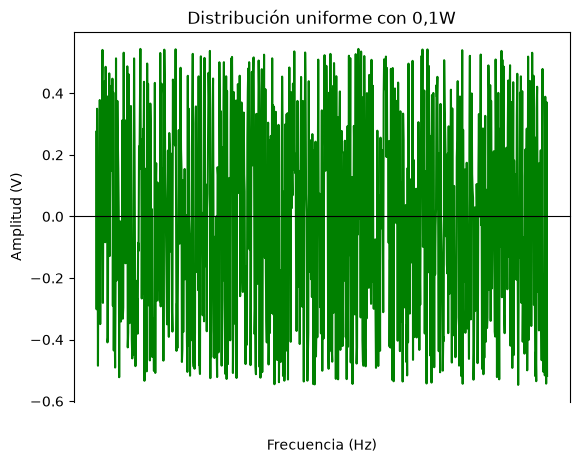

In [13]:
fs=1000
tt=np.arange(N)
#media=(a+b)/2=0
#a=-b
#var=(b-a)**2/12=0,1W
#var=(2b)**2/12=0,1W

b=(np.sqrt(1.2))/2
a=-b
unif=np.random.uniform(low=a,high=b,size=len(tt))

plt.figure(10)
plt.plot(tt, unif, color="green")
plt.title("Distribución uniforme con 0,1W")
plt.gca().spines['bottom'].set_position('zero')
plt.xticks([], [])
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

Para el ruido con distribución normal se debieron realizar cálculos para encontrar la manera de que disponga de valor medio de 0V y varianza de 0,1W. En primer lugar, se tuvieron en cuenta las siguientes fórmulas correspondientes a distribuciones normales:

\begin{equation}
Media=\frac{a+b}{2} \wedge Varianza=\frac{(b-a)^2}{12}
\end{equation}

Como la media debe ser nula y la potencia debe ser igual a 0,1W
\begin{equation}
0=\frac{a+b}{2}\Longrightarrow b=-a \wedge 0,1=\frac{(2*b)^2}{12}\Longrightarrow b=\frac{\sqrt{1,2}}{2}
\end{equation}

De esta manera, podemos completar los parámetros propios de la función *np.random.uniform*: *low*=a, *high*=b. En el gráfico de la función podemos ver que se respeta el valor medio, y si imprimimos la varianza de la función *unif* veremos que se asemeja al valor esperado:

In [14]:
print(a,b,np.var(unif))

-0.5477225575051661 0.5477225575051661 0.10378827560004697


Text(0.5, 0, 'Frecuencia (Hz)')

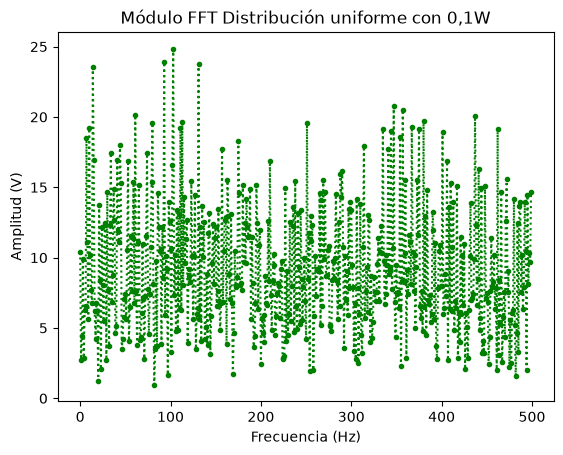

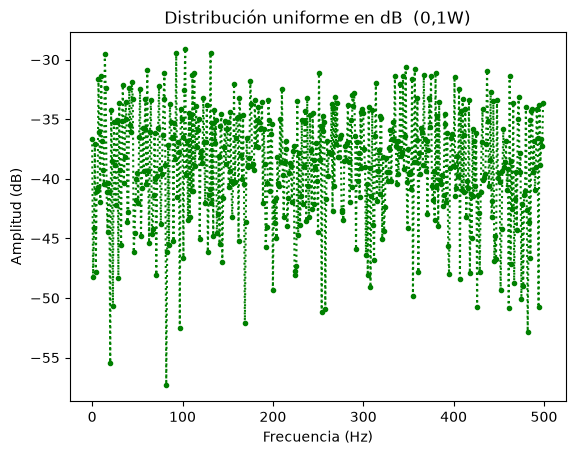

In [15]:
fftunif = fft(unif)
fftunif = fftunif[:N//2]
fftunif_abs = np.abs(fftunif)
freq = fftfreq(N,1/fs)
freq = freq[:N//2]

plt.figure(11)
plt.plot(freq,fftunif_abs, ":.", color="green")
plt.title("Módulo FFT Distribución uniforme con 0,1W")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

fftunif_abs_dB=20*np.log10(fftunif_abs/ref)

plt.figure(12)
plt.plot(freq, fftunif_abs_dB, ":.", color="green")
plt.title("Distribución uniforme en dB  (0,1W)")
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")

Nuevamente, al igual que en el ruido distribuido normalmente, el gráfico en decibeles de la FFT aparenta respetar los valores más altos del módulo de la FFT. Busco el máximo de la misma manera que antes:

In [16]:
A=20*np.log10((np.max(fftunif_abs))/ref)
print(np.max(fftunif_abs))
print(A)

24.850667057276826
-29.082939026716627


Los resultados parecen coincidir con lo mostrado gráficamente. Por el contrario, con los valores más cercanos a cero de la primera gráfica, se ve que luego se diferencian bastante cuando se los traduce a decibeles. Esto es una propiedad que genera el $\log_{10}$. Si calculamos nuevamente, pero con el mínimo del módulo de la FFT, tenemos:

In [17]:
A=20*np.log10((np.min(fftunif_abs))/ref)
print(np.min(fftunif_abs))
print(A)

0.9684192877179439
-57.26843143197178


#### 5° Señal:
Un pulso rectangular de la misma frecuencia (2kHz), 1 W de potencia y ciclo de actividad del 50%

Text(0.5, 0, 'Frecuencia (Hz)')

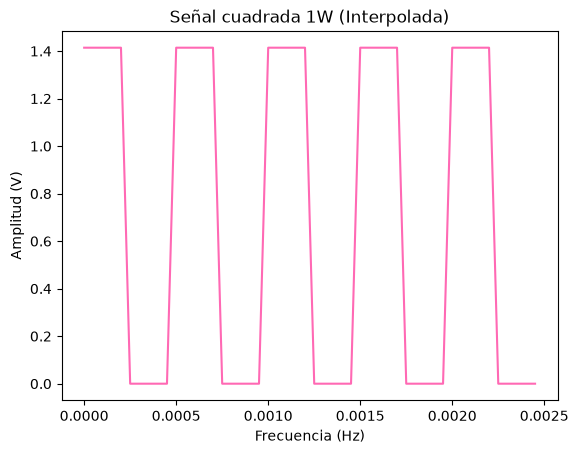

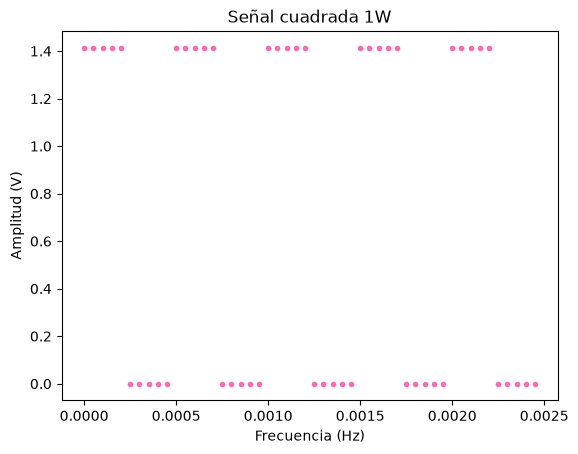

In [18]:
fs=20000
tt=np.arange(0,N/fs, 1/fs)
cuadr=((square(tt*2*np.pi*2000, duty=0.5)+1)/2)*np.sqrt((2))

plt.figure(13)
plt.plot(tt[:50], cuadr[:50], color="hotpink")
plt.title("Señal cuadrada 1W (Interpolada)")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

plt.figure(14)
plt.plot(tt[:50], cuadr[:50], color="hotpink", linestyle=" ", marker=".")
plt.title("Señal cuadrada 1W")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

Para generar la señal cuadrada, primero se buscó la manera de utilizar la función *scipy.signal.square*. Uno de los parámetros es el *t*, en el que se involucra la frecuencia *ff*, y el otro parámetro sería *duty*, el cual define la actividad, en este caso, del 50% (no es realmente necesario indicarlo en la función esta vez, ya que ese es el valor predeterminado). Además, la función *square* opera entre los valores $\pm1$, por lo que se le generó un corrimiento con $+1$ junto a la función *square*. Entonces, la función ejerció valores mínimo=0 y máximo=2, por lo que se multiplicó la función por $\frac{1}{2}$, reduciendo la amplitud de la señal a la mitad. Finalmente, como se busca que la señal cuadrada tenga una potencia de 1W, se le aplicó una amplitud de $\sqrt{2}$. 

Corroboro la potencia, en este caso, mediante la función *np.mean* con la función *cuadr* al cuadrado, ya que la función *np.var* se utiliza en el caso en que la media sea nula. Entonces:

In [19]:
print(np.mean(cuadr**2))

1.0180000000000002


Luego, se pueden observar dos gráficos, uno con una interpolación generada por el método de graficación y el otro con *linestyle* vacío. A partir de sus diferencias, notamos cómo es que el código recrea puntos inexistentes, "de relleno".

Cabe aclarar, que en las figuras se observan 5 períodos, debido a dos cosas. Primero, se respetó la misma idea que en las señales sinusoidales, de contar con 10 puntos por período. En segundo lugar, al momento del ploteo, se pidió que se tomaran hasta 50 puntos, para poder apreciar ampliamente la señal cuadrada (decisión propia).

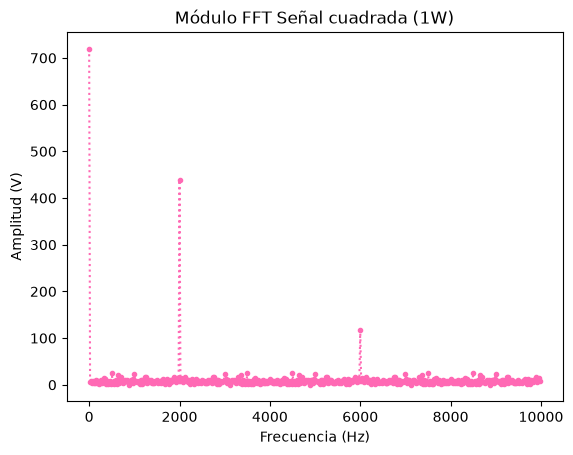

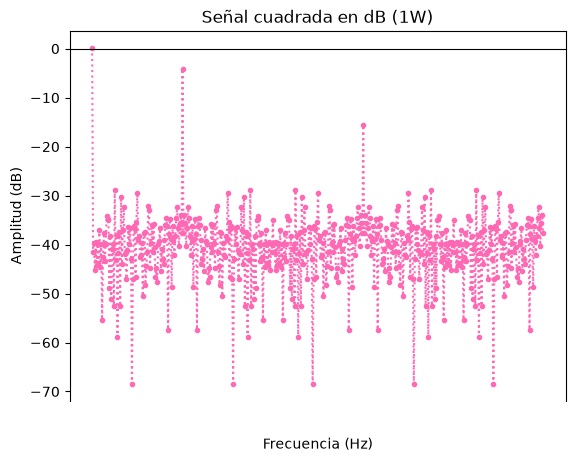

In [20]:
fftcuadr = fft(cuadr)
fftcuadr = fftcuadr[:N//2]
fftcuadr_abs = np.abs(fftcuadr)
freq = fftfreq(N,1/fs)
freq = freq[:N//2]

plt.figure(14)
plt.plot(freq,fftcuadr_abs, ":.", color="hotpink")
plt.title("Módulo FFT Señal cuadrada (1W)")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

fftcuadr_abs_dB=20*np.log10(fftcuadr_abs/ref)

plt.figure(12)
plt.plot(freq, fftcuadr_abs_dB, ":.", color="hotpink")
plt.title("Señal cuadrada en dB (1W)")
plt.gca().spines['bottom'].set_position('zero')
plt.xticks([], [])
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

En esta señal cuadrada podemos observar varios picos en la FFT, en las frecuencias 0, 2000 y 6000, que decaen progresivamente. Esto se debe a la definición de una señal cuadrada; se trata de una sumatoria trigonométrica, en este caso, de senos. 

En la posición de 0Hz, la función *cuadr* respeta la constante que acompaña a la función *square*, que en este caso, coincide aproximadamente con la amplitud de la primera señal sinusoidal analizada; $\sqrt{2}$. Es por eso, que coinciden en amplitud en el módulo de la FFT. Luego, los valores de 2000Hz y 6000Hz son aquellos en los que la sumatoria de los senos involucrados será relevante. Aquí, se trata de múltimplos impares (por el seno) de la frecuencia *ff*=2000Hz.

In [21]:
print(fftcuadr_abs[freq==0], fftcuadr_abs[freq==2000], fftcuadr_abs[freq==6000])

[719.83470325] [438.73080482] [116.61595474]


In [22]:
print(fftcuadr_abs_dB[freq==0], fftcuadr_abs_dB[freq==2000], fftcuadr_abs_dB[freq==6000])

[0.15495556] [-4.14573747] [-15.6545406]


#### Señal extra:
Un pulso de diente de sierra de la misma frecuencia (2kHz) y 1 W de potencia

Text(0.5, 0, 'Frecuencia (Hz)')

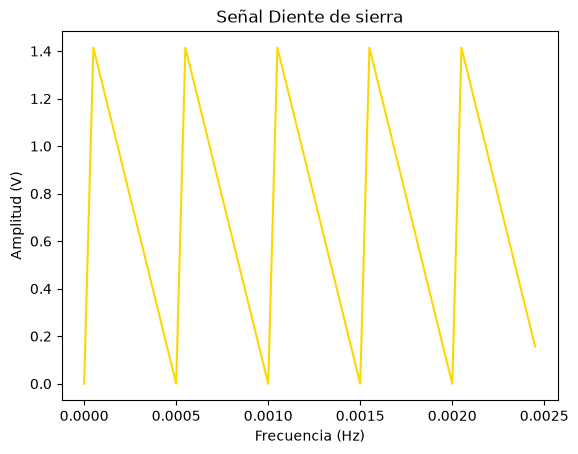

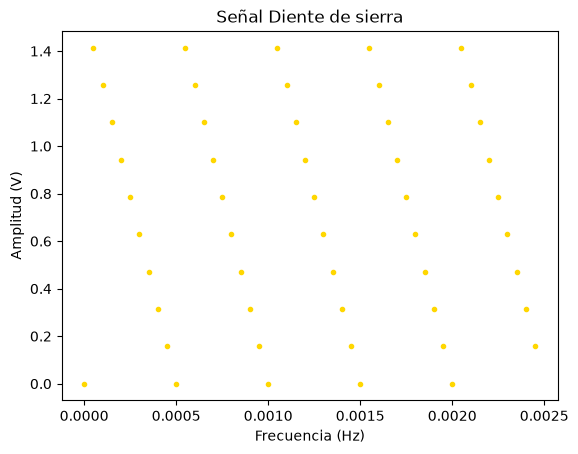

In [44]:
fs=20000
tt=np.arange(0,N/fs, 1/fs)
saw=((sawtooth(tt*2*np.pi*2000, width=0.1)+1)/2)*np.sqrt((2))
pot=np.mean(saw**2)

plt.figure(16)
plt.plot(tt[:50], saw[:50], color="gold")
plt.title("Señal Diente de sierra")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

plt.figure(17)
plt.plot(tt[:50], saw[:50], color="gold", linestyle=" ", marker=".")
plt.title("Señal Diente de sierra")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

Esta última señal se relaciona bastante a la cuadrada, por lo que se le indicó la misma frecuencia, misma cantidad de puntos por períodos y misma amplitud. Esto facilitó la manipulación de la función *sawtooth*, ya que es bastante similar a la previa (*square*). Nuevamente, si dejamos de lado la primer figura, la cual está interpolada por la función *plot*, podemos encontrar un salto repentino entre el primer y el segundo punto.

Para ver el comportamiento de esta señal en cuanto a la potencia, calculamos:

In [42]:
print(np.mean(saw**2))

0.7037037037036955


Vemos ahora que no coincide la potencia, lo cual se debe probablemente al formato de la función, su distribución a lo largo de la frecuencia.

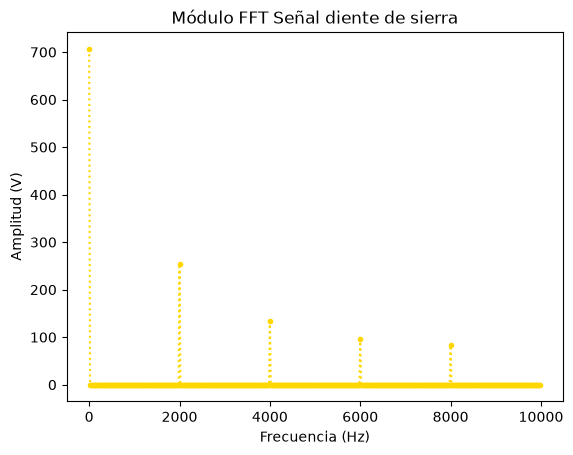

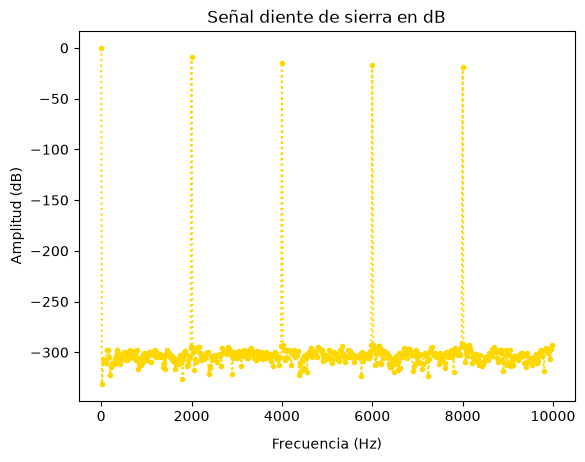

In [48]:
fftsaw = fft(saw)
fftsaw = fftsaw[:N//2]
fftsaw_abs = np.abs(fftsaw)
freq = fftfreq(N,1/fs)
freq = freq[:N//2]

plt.figure(17)
plt.plot(freq,fftsaw_abs, ":.", color="gold")
plt.title("Módulo FFT Señal diente de sierra")
plt.ylabel("Amplitud (V)")
plt.xlabel("Frecuencia (Hz)")

fftsaw_abs_dB=20*np.log10(fftsaw_abs/ref)

plt.figure(18)
plt.plot(freq, fftsaw_abs_dB, ":.", color="gold")
plt.title("Señal diente de sierra en dB")
plt.ylabel("Amplitud (dB)")
plt.xlabel("Frecuencia (Hz)")
plt.gca().xaxis.set_label_coords(0.5, -0.1)

La primer figura demuestra varios deltas, los cuales aparentan seguir una linea de caída exponencial. Además, se repiten cada 2000Hz, por lo que, retomando lo dicho previamente con la señal cuadrada, probablemente el pulso de diente de sierra se trate de una suma de tanto senos como cosenos, por lo que contamos de múltimos de *ff* pares e impares.

Por último, vemos que pasando esta señal a una relación en dB, los picos se mantienen muy cercanos en amplitud, a la vez que los valores mínimos tienden a juntarse en los valores negativos aproximadamente por el -300.

#### Conclusiones
Las señales analizadas variaron todas en amplitud, fase, frecuencia y potencias. Se encontraron varias similitudes, como las funciones senoidales con la cuadrada, y los comportamiento aleatorios de las señales de ruido de distribución normal e uniforme. 
A medida que se trabajó con esta tarea, se tuvieron que desarrollar fórmulas vistas en clase y se pusieron en práctica para conseguir los valores esperados, como el caso de las potencias.

A partir de la primer función creada, llevamos nuestras otras señales en función de la amplitud con respecto a las potencias, a que estén en función de los decibeles, relacionados a un *ref* vinculado a la amplitud de 1W de la sinusoidal. Así, se pudo diferenciar los valores significativos de los chicos mediante las propiedades del $log_{10}$